# 04-Pydantic & Mathematical Validation

In Lesson 03, we built the FastAPI routing layer. We proved that we can receive JSON payloads and map them into PyTorch tensors.

However, in an Enterprise production environment, **the outside world is highly toxic**.
If a client sends an LLM generation request with `"temperature": -5.0`, and that payload reaches your PyTorch model, the Softmax equation ($P(x_i) = \frac{\exp(z_i / T)}{\sum \exp(z_j / T)}$) will mathematically collapse. The GPU will throw a low-level CUDA assertion error, the server will crash, and all other users currently being processed will be disconnected.

To protect the expensive, fragile mathematics of the GPU, we must build an impenetrable firewall at the edge of our API. In modern Python, the absolute industry standard for this is **Pydantic**.

Let's set up our environment to master rigorous schema enforcement.

In [1]:
import torch
import torch.nn.functional as F
from pydantic import BaseModel, Field, model_validator, ValidationError
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch & Pydantic Data Engineering Environment Ready.")

✅ PyTorch & Pydantic Data Engineering Environment Ready.


# 1. The Danger of Standard Python Dictionaries

Historically, Python developers used loose dictionaries to pass data:
`payload = {"temperature": 1.5, "max_tokens": "five hundred"}`

This is catastrophically dangerous for Machine Learning for three reasons:

1. **Type Corruption**: `max_tokens` is a string. PyTorch requires an integer for tensor dimension sizing.
2. **Silent Boundary Violations**: A temperature of `1000.0` is a valid float, but it will cause mathematical overflow (NaN) inside the Neural Network's exponential functions.
3. **Missing Context**: If the client forgets to send `top_p`, the dictionary simply lacks the key, causing a `KeyError` deep inside the inference loop.

# 2. Pydantic: The Mathematical Bouncer

**Pydantic** forces incoming JSON to conform to rigid, mathematically bounded classes before it is ever allowed to touch your PyTorch code.

If we are hosting a Large Language Model (LLM), we must strictly bound the generation hyper-parameters.

* **Temperature ($T$)**: Must be strictly greater than $0.0$ (to prevent division by zero in the Softmax scale) and less than or equal to $2.0$ (to prevent exponential overflow).
* **Top-p ($p$)**: A probability mass, meaning it must mathematically fall within $(0.0, 1.0]$.
* **Max Tokens ($N$)**: An integer strictly between $1$ and the model's absolute maximum context window (e.g., $4096$).

Let's construct this impenetrable firewall using Pydantic's `Field` constraints.

In [2]:
# 1. Architecting the LLM Generation Schema
class LLMGenerationRequest(BaseModel):
    # The prompt must be a string, and cannot be completely empty
    prompt: str = Field(..., min_length=1, description="The input text sequence.")
    
    # Bounding the Calculus of Generation
    temperature: float = Field(
        default=0.7, 
        gt=0.0,      # strictly Greater Than 0.0
        le=2.0,      # Less than or Equal to 2.0
        description="Scales the logits before softmax. T > 0."
    )
    
    top_p: float = Field(
        default=0.95, 
        gt=0.0, 
        le=1.0, 
        description="Nucleus sampling probability mass threshold."
    )
    
    max_tokens: int = Field(
        default=256, 
        ge=1,        # Greater than or Equal to 1
        le=4096,     # Absolute model context limit
        description="Maximum sequence length for autoregression."
    )

print("--- 🛡️ Pydantic Firewall Compiled ---")

--- 🛡️ Pydantic Firewall Compiled ---


# 3. Executing the Validation Physics

Let's simulate an API endpoint receiving payloads from three different client machines. We will see how Pydantic cleanly handles clean data, type coercion, and malicious/erroneous data without ever executing a single line of PyTorch.

In [3]:
# --- Simulated Client Payloads ---

# 1. The Perfect Client
perfect_payload = {
    "prompt": "Explain the theory of relativity.",
    "temperature": 0.5,
    "top_p": 0.9,
    "max_tokens": 1024
}

# 2. The Sloppy Client (Sending strings instead of ints/floats)
sloppy_payload = {
    "prompt": "Write a poem.",
    "temperature": "1.2",      # String!
    "max_tokens": "500"        # String!
}

# 3. The Dangerous Client (Mathematically violating the neural network bounds)
dangerous_payload = {
    "prompt": "HACK THE SYSTEM",
    "temperature": -0.5,       # FATAL: Negative temperature
    "top_p": 1.5,              # FATAL: Probability > 1.0
    "max_tokens": 100000       # FATAL: Exceeds GPU VRAM limit
}

print("\n--- 🔬 Executing Validation Tests ---")

def process_payload(payload_dict, name):
    print(f"\nEvaluating {name}...")
    try:
        # The exact moment of validation
        validated_data = LLMGenerationRequest(**payload_dict)
        print(f"✅ Success! Data is safe for GPU: {validated_data.model_dump()}")
    except ValidationError as e:
        print(f"❌ BLOCKED! Pydantic intercepted fatal errors:")
        # Pydantic generates beautiful, machine-readable error traces
        for error in e.errors():
            print(f"   - Field '{error['loc'][0]}': {error['msg']}")

process_payload(perfect_payload, "Perfect Payload")

print("\nNotice on Sloppy Payload: Pydantic automatically performs Type Coercion! It realizes '1.2' is a string, but cleanly casts it to a float to save the API from crashing.")
process_payload(sloppy_payload, "Sloppy Payload")

process_payload(dangerous_payload, "Dangerous Payload")


--- 🔬 Executing Validation Tests ---

Evaluating Perfect Payload...
✅ Success! Data is safe for GPU: {'prompt': 'Explain the theory of relativity.', 'temperature': 0.5, 'top_p': 0.9, 'max_tokens': 1024}

Notice on Sloppy Payload: Pydantic automatically performs Type Coercion! It realizes '1.2' is a string, but cleanly casts it to a float to save the API from crashing.

Evaluating Sloppy Payload...
✅ Success! Data is safe for GPU: {'prompt': 'Write a poem.', 'temperature': 1.2, 'top_p': 0.95, 'max_tokens': 500}

Evaluating Dangerous Payload...
❌ BLOCKED! Pydantic intercepted fatal errors:
   - Field 'temperature': Input should be greater than 0
   - Field 'top_p': Input should be less than or equal to 1
   - Field 'max_tokens': Input should be less than or equal to 4096


# 4. Complex Geometric Validation (`@model_validator`)

Field constraints (`gt`, `le`) are great for single variables. But what if the validation logic requires checking **two variables against each other**?

Imagine an Object Detection (Computer Vision) API. The client sends a Bounding Box crop request: $[x_{min}, y_{min}, x_{max}, y_{max}]$.
If $x_{min}$ is larger than $x_{max}$, the PyTorch slicing operation `image[:, ymin:ymax, xmin:xmax]` will yield a tensor of size $0$, destroying the downstream convolution layers.

We must use Pydantic's `@model_validator` to enforce complex geometric physics across multiple fields.

In [4]:
# Architecting Geometric Computer Vision Constraints
class BoundingBoxCropRequest(BaseModel):
    x_min: int = Field(..., ge=0)
    y_min: int = Field(..., ge=0)
    x_max: int = Field(..., gt=0)
    y_max: int = Field(..., gt=0)
    
    @model_validator(mode='after')
    def validate_spatial_geometry(self):
        # 1. Enforce Euclidean Width
        if self.x_min >= self.x_max:
            raise ValueError(f"Spatial Violation: x_min ({self.x_min}) must be strictly less than x_max ({self.x_max}).")
            
        # 2. Enforce Euclidean Height
        if self.y_min >= self.y_max:
            raise ValueError(f"Spatial Violation: y_min ({self.y_min}) must be strictly less than y_max ({self.y_max}).")
            
        # 3. Enforce Minimum Area (Prevent 1x1 pixel slices that crash CNNs)
        area = (self.x_max - self.x_min) * (self.y_max - self.y_min)
        if area < 16:
            raise ValueError(f"Area Violation: Resulting crop area ({area} px) is too small for the CNN. Minimum is 16 px.")
            
        return self

print("\n--- 📐 Testing Geometric Bounding Box Validation ---")
try:
    # Simulating a completely inverted bounding box selection
    bad_bbox = BoundingBoxCropRequest(x_min=500, y_min=300, x_max=100, y_max=400)
except ValidationError as e:
    print("❌ BLOCKED! Spatial Geometry Violation Intercepted:")
    print(e.errors()[0]['msg'])


--- 📐 Testing Geometric Bounding Box Validation ---
❌ BLOCKED! Spatial Geometry Violation Intercepted:
Value error, Spatial Violation: x_min (500) must be strictly less than x_max (100).


# 5. Visualizing the Mathematical Sandbox

To truly understand what Pydantic is doing, we can map its validation constraints as a strict geometric boundary in 2D space.
For our LLM Hyperparameters, any coordinate ($T$, $p$) outside the allowed boundary is mathematically walled off before it can reach the Neural Network.

/tmp/ipykernel_3893/3807777799.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3893/3807777799.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


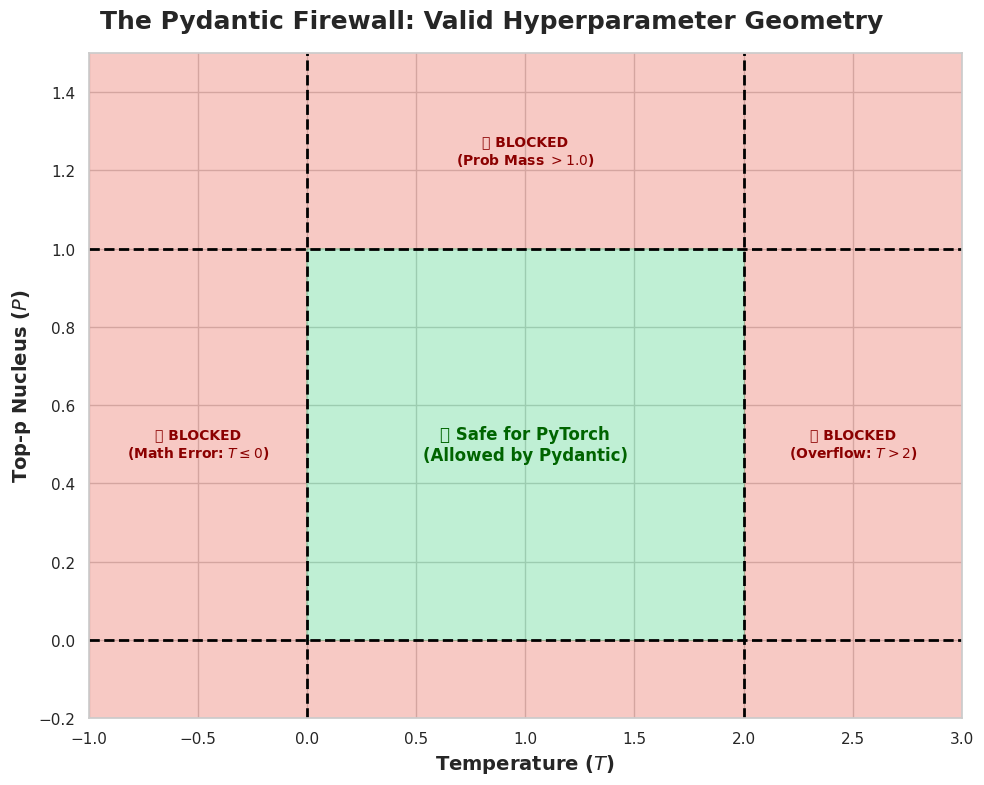


--- 💡 Engineering Insight ---
Look at the visualization. Before Pydantic, your API route was a vast, open red grid. Any client could request any coordinate, forcing you to write dozens of 'if/else' statements to catch edge cases, or worse, letting the request reach the GPU and trigger a CUDA memory dump.
By using Pydantic, FastAPI mathematically guarantees that ONLY requests landing cleanly inside the green rectangle will ever execute your route function. The backend is completely sanitized.


In [5]:
# Generate a dense grid of possible API requests
temperature_space = np.linspace(-1.0, 3.0, 400)
top_p_space = np.linspace(-0.2, 1.5, 400)
T, P = np.meshgrid(temperature_space, top_p_space)

# Define the Pydantic mathematical boundaries
valid_mask = (T > 0.0) & (T <= 2.0) & (P > 0.0) & (P <= 1.0)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("The Pydantic Firewall: Valid Hyperparameter Geometry", fontsize=18, fontweight='bold')

# Plot the safe zone vs the danger zone
cmap = plt.matplotlib.colors.ListedColormap(['#e74c3c', '#2ecc71']) # Red (Blocked), Green (Allowed)
plt.contourf(T, P, valid_mask, cmap=cmap, alpha=0.3)

# Draw the strict boundary lines
plt.axvline(x=0.0, color='black', linestyle='--', linewidth=2)
plt.axvline(x=2.0, color='black', linestyle='--', linewidth=2)
plt.axhline(y=0.0, color='black', linestyle='--', linewidth=2)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)

ax.set_xlabel("Temperature ($T$)", fontsize=14, fontweight='bold')
ax.set_ylabel("Top-p Nucleus ($P$)", fontsize=14, fontweight='bold')

# Annotations
ax.text(1.0, 0.5, "✅ Safe for PyTorch\n(Allowed by Pydantic)", 
        fontsize=12, fontweight='bold', ha='center', va='center', color='darkgreen')
ax.text(-0.5, 0.5, "❌ BLOCKED\n(Math Error: $T \\leq 0$)", 
        fontsize=10, fontweight='bold', ha='center', va='center', color='darkred')
ax.text(2.5, 0.5, "❌ BLOCKED\n(Overflow: $T > 2$)", 
        fontsize=10, fontweight='bold', ha='center', va='center', color='darkred')
ax.text(1.0, 1.25, "❌ BLOCKED\n(Prob Mass $> 1.0$)", 
        fontsize=10, fontweight='bold', ha='center', va='center', color='darkred')

plt.xlim(-1.0, 3.0)
plt.ylim(-0.2, 1.5)
plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the visualization. Before Pydantic, your API route was a vast, open red grid. Any client could request any coordinate, forcing you to write dozens of 'if/else' statements to catch edge cases, or worse, letting the request reach the GPU and trigger a CUDA memory dump.")
print("By using Pydantic, FastAPI mathematically guarantees that ONLY requests landing cleanly inside the green rectangle will ever execute your route function. The backend is completely sanitized.")

## Real-World Use Case or Analogy:

Think of Pydantic like **The Bouncer at an Exclusive Nightclub**:

* **Standard Python Dictionary (An Open Door)**: Anyone can walk into the nightclub. A teenager, a person with a live tiger, a person carrying a sledgehammer. The bartender (Your PyTorch Model) has to deal with the chaos. When the person swings the sledgehammer, the bartender gets hit, the club catches fire, and everyone is evacuated (Server Crash).
* **Pydantic (The Bouncer)**: The bouncer stands outside the door with a rigid clipboard (The Schema).
* If you don't have an ID (Missing Required Field), you are rejected immediately.
* If your ID says you are 12 years old (Type/Boundary Violation), you are rejected immediately.
* If you try to hand the bouncer a piece of paper that says "Twenty-One" instead of a real ID (Sloppy Data), the bouncer is smart enough to translate it, stamp your hand, and let you in (Type Coercion).
* The bartender (The PyTorch Model) never has to worry about security. They are mathematically guaranteed that every single person who reaches the bar is 21+, wearing shoes, and unarmed. They can focus 100% of their energy on making drinks (Matrix Multiplication).